In [ ]:
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# BFS
def bfs(graph, start, goal):
    visited = set()
    queue = deque([start])

    while queue:
        node = queue.popleft()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            queue.extend(graph[node])

    return False


# DFS
def dfs(graph, start, goal):
    visited = set()
    stack = [start]

    while stack:
        node = stack.pop()

        if node == goal:
            return True

        if node not in visited:
            visited.add(node)
            stack.extend(graph[node])

    return False


print("BFS:", bfs(graph, 'A', 'F'))
print("DFS:", dfs(graph, 'A', 'F'))

BFS: True
DFS: True


    Size  BFS Time  DFS Time
0   1000  0.000144  0.000369
1   4000  0.000188  0.000753
2   8000  0.000729  0.002044
3  20000  0.006367  0.005104
4  10000  0.001440  0.001754


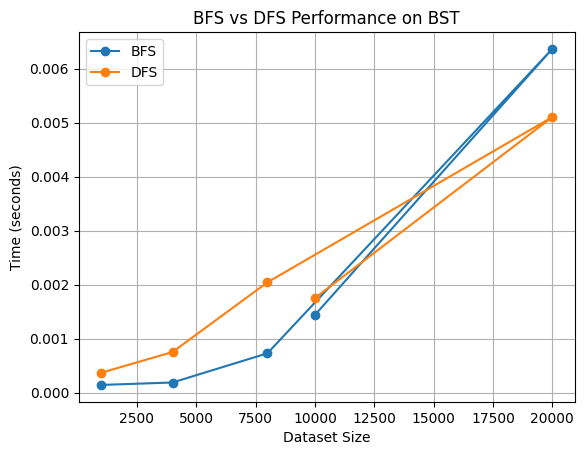

In [ ]:
import random
import time
from collections import deque
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Generate datasets
sizes = [1000, 4000, 8000, 20000, 10000]   # reduced sizes (20M will crash your system)
datasets = []

for size in sizes:
    data = random.sample(range(size * 10), size)
    datasets.append(data)


# Step 2: Binary Search Tree
class Node:
    def __init__(self, value):
        self.value = value
        self.left = None
        self.right = None


def insert(root, value):
    if root is None:
        return Node(value)

    if value < root.value:
        root.left = insert(root.left, value)
    else:
        root.right = insert(root.right, value)

    return root


# Step 3: BFS and DFS on Tree
def bfs_tree(root, goal):
    queue = deque([root])

    while queue:
        node = queue.popleft()

        if node.value == goal:
            return True

        if node.left:
            queue.append(node.left)
        if node.right:
            queue.append(node.right)

    return False


def dfs_tree(root, goal):
    stack = [root]

    while stack:
        node = stack.pop()

        if node.value == goal:
            return True

        if node.left:
            stack.append(node.left)
        if node.right:
            stack.append(node.right)

    return False


# Step 4: Run Experiment
results = []

for data in datasets:
    root = None

    # build tree
    for value in data:
        root = insert(root, value)

    goal = data[len(data) - 1]  # last element

    # BFS timing
    start_time = time.time()
    bfs_tree(root, goal)
    bfs_time = time.time() - start_time

    # DFS timing
    start_time = time.time()
    dfs_tree(root, goal)
    dfs_time = time.time() - start_time

    results.append([len(data), bfs_time, dfs_time])

# DataFrame
df = pd.DataFrame(results, columns=["Size", "BFS Time", "DFS Time"])
print(df)


# Step 5: Plot Graph
plt.plot(df["Size"], df["BFS Time"], marker='o', label="BFS")
plt.plot(df["Size"], df["DFS Time"], marker='o', label="DFS")

plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")
plt.title("BFS vs DFS Performance on BST")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from collections import deque

graph = {
    "Islamabad": ["Rawalpindi", "Lahore", "Peshawar"],
    "Rawalpindi": ["Islamabad", "Peshawar", "Quetta"],
    "Peshawar": ["Islamabad", "Rawalpindi", "Quetta"],
    "Lahore": ["Islamabad", "Quetta"],
    "Quetta": ["Rawalpindi", "Peshawar", "Lahore"]
}

def shortest_path(graph, start, goal):
    queue = deque([[start]])   # queue of paths
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node == goal:
            return path

        if node not in visited:
            visited.add(node)

            for neighbour in graph[node]:
                new_path = list(path)
                new_path.append(neighbour)
                queue.append(new_path)

    return None


# call function
print(shortest_path(graph, "Islamabad", "Quetta"))

['Islamabad', 'Rawalpindi', 'Quetta']
